# Análisis Exploratorio de Datos (EDA)
## Telco Customer Churn - IBM Dataset

**Objetivo:** Comprender la estructura, calidad y patrones del dataset antes de modelar.

## 1. Carga de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de Datos

In [2]:
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones: 7043 filas x 33 columnas


## 3. Primeras Filas

In [3]:
df.head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


## 4. Tipos de Datos

In [4]:
df.dtypes.to_frame('Tipo de Dato')

,Tipo de Dato
CustomerID,str
Count,int64
Country,str
State,str
City,str
Zip Code,int64
Lat Long,str
Latitude,float64
Longitude,float64
Gender,str


## 5. Valores Nulos

In [5]:
nulls = df.isnull().sum()
nulls[nulls > 0] if any(nulls > 0) else print("No hay valores nulos en el dataset.")
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")


Total de valores nulos: 5174


## 6. Valores Duplicados

In [6]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


## 7. Estadísticas Descriptivas - Variables Numéricas

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


## 8. Distribución de la Variable Objetivo (Churn)

Distribución del Churn:
  No Churn (0): 5174 (73.5%)
  Churn (1):    1869 (26.5%)


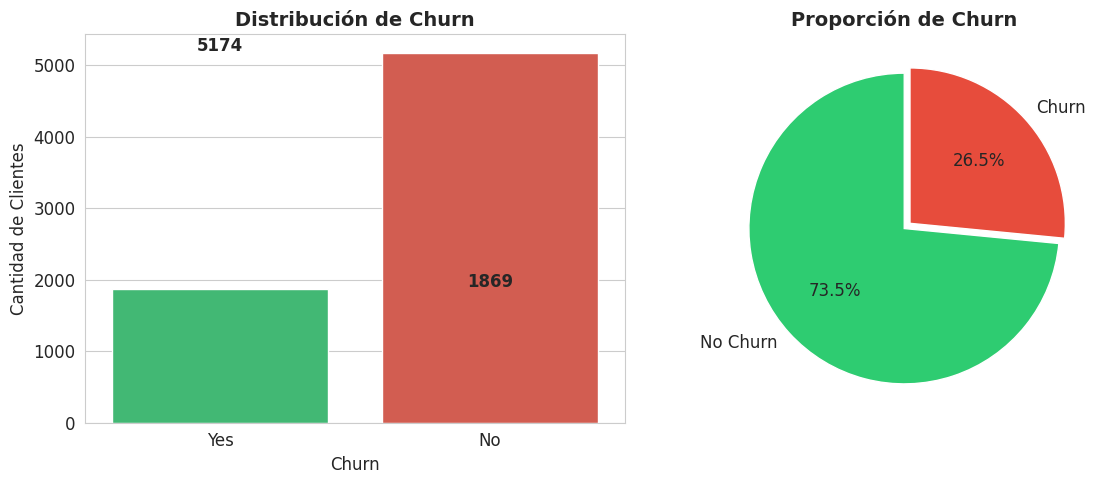

In [8]:
# Usar Churn Value (0/1) como target
target_counts = df['Churn Value'].value_counts()
print("Distribución del Churn:")
print(f"  No Churn (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"  Churn (1):    {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

# Countplot
sns.countplot(data=df, x='Churn Label', palette=colors, ax=axes[0])
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Análisis de Variables Numéricas

### 9.1 Tenure Months (Antigüedad)

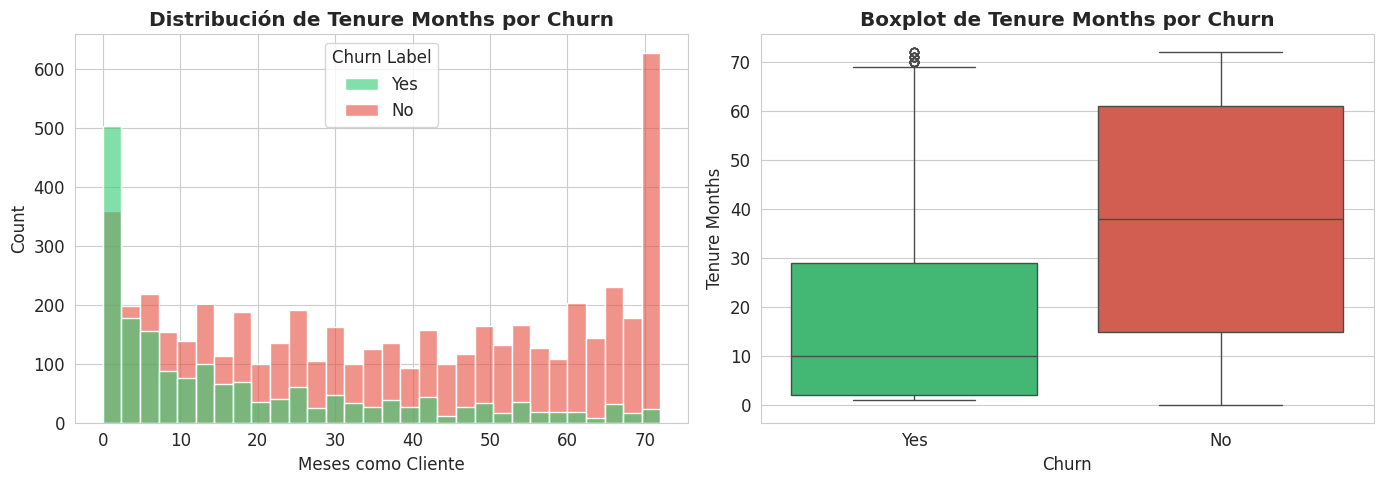


Estadísticas de Tenure Months por grupo:
              count  mean   std  min   25%   50%   75%   max
Churn Label                                                 
No           5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Yes          1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Tenure Months', hue='Churn Label', palette=colors,
             bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Distribución de Tenure Months por Churn', fontweight='bold')
axes[0].set_xlabel('Meses como Cliente')

sns.boxplot(data=df, x='Churn Label', y='Tenure Months', palette=colors, ax=axes[1])
axes[1].set_title('Boxplot de Tenure Months por Churn', fontweight='bold')
axes[1].set_xlabel('Churn')

plt.tight_layout()
plt.savefig('../reports/figures/tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEstadísticas de Tenure Months por grupo:")
print(df.groupby('Churn Label')['Tenure Months'].describe().round(1))

### 9.2 Monthly Charges

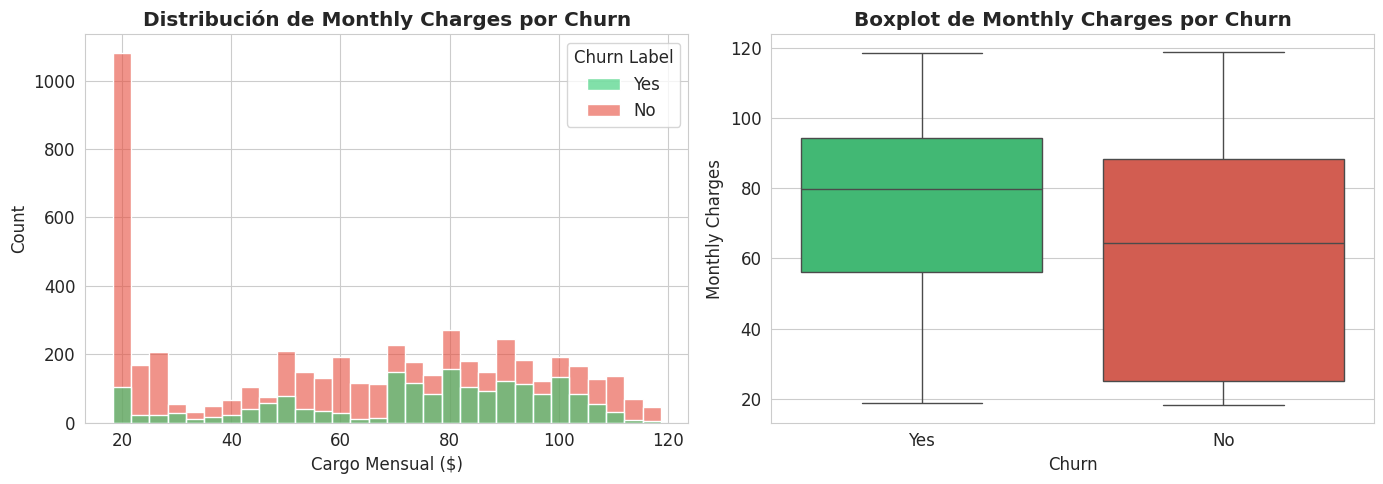


Estadísticas de Monthly Charges por grupo:
              count  mean   std   min   25%   50%   75%    max
Churn Label                                                   
No           5174.0  61.3  31.1  18.2  25.1  64.4  88.4  118.8
Yes          1869.0  74.4  24.7  18.8  56.2  79.6  94.2  118.4


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Monthly Charges', hue='Churn Label', palette=colors,
             bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Distribución de Monthly Charges por Churn', fontweight='bold')
axes[0].set_xlabel('Cargo Mensual ($)')

sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', palette=colors, ax=axes[1])
axes[1].set_title('Boxplot de Monthly Charges por Churn', fontweight='bold')
axes[1].set_xlabel('Churn')

plt.tight_layout()
plt.savefig('../reports/figures/monthly_charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEstadísticas de Monthly Charges por grupo:")
print(df.groupby('Churn Label')['Monthly Charges'].describe().round(1))

### 9.3 Total Charges

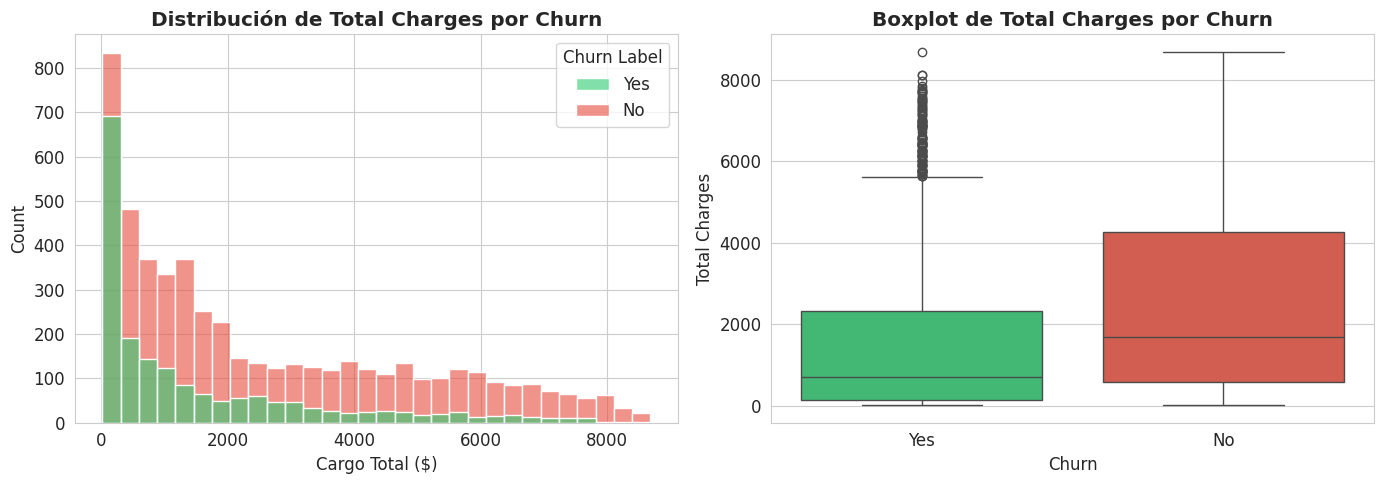


Estadísticas de Total Charges por grupo:
              count    mean     std   min    25%     50%     75%     max
Churn Label                                                             
No           5163.0  2555.3  2329.5  18.8  577.8  1683.6  4264.1  8672.4
Yes          1869.0  1531.8  1890.8  18.8  134.5   703.6  2331.3  8684.8


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot['Total Charges'] = pd.to_numeric(df_plot['Total Charges'], errors='coerce')

sns.histplot(data=df_plot, x='Total Charges', hue='Churn Label', palette=colors,
             bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Distribución de Total Charges por Churn', fontweight='bold')
axes[0].set_xlabel('Cargo Total ($)')

sns.boxplot(data=df_plot, x='Churn Label', y='Total Charges', palette=colors, ax=axes[1])
axes[1].set_title('Boxplot de Total Charges por Churn', fontweight='bold')
axes[1].set_xlabel('Churn')

plt.tight_layout()
plt.savefig('../reports/figures/total_charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEstadísticas de Total Charges por grupo:")
print(df_plot.groupby('Churn Label')['Total Charges'].describe().round(1))

## 10. Análisis de Variables Categóricas

### 10.1 Contract (Tipo de Contrato)

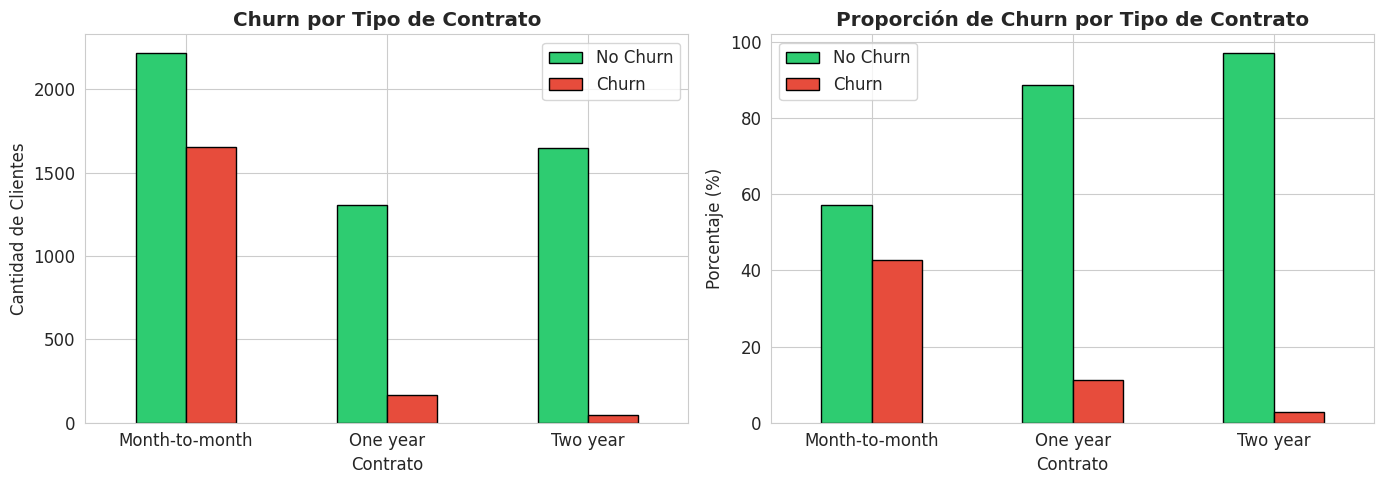


Tasa de Churn por tipo de contrato:
  Month-to-month: 42.7%
  Two year: 2.8%
  One year: 11.3%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_cross = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index') * 100
ct_counts = pd.crosstab(df['Contract'], df['Churn Label'])

ct_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn por Tipo de Contrato', fontweight='bold')
axes[0].set_xlabel('Contrato')
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].legend(['No Churn', 'Churn'])
axes[0].tick_params(axis='x', rotation=0)

ct_cross.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Proporción de Churn por Tipo de Contrato', fontweight='bold')
axes[1].set_xlabel('Contrato')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['No Churn', 'Churn'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/contract_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTasa de Churn por tipo de contrato:")
for contract in df['Contract'].unique():
    subset = df[df['Contract'] == contract]
    rate = subset['Churn Value'].mean() * 100
    print(f"  {contract}: {rate:.1f}%")

### 10.2 Internet Service

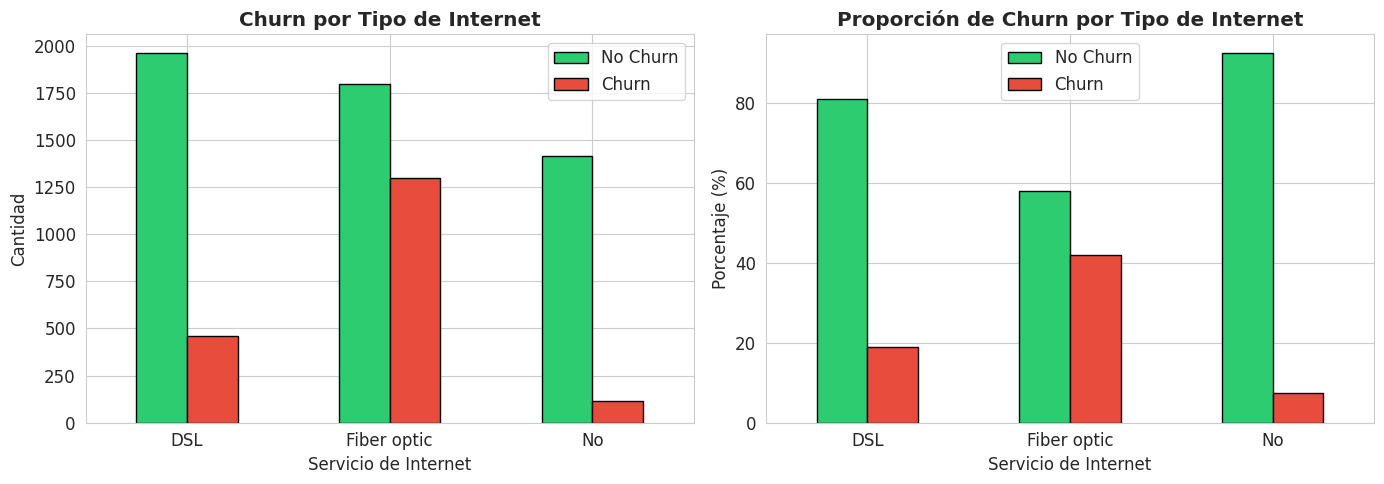


Tasa de Churn por tipo de Internet:
  DSL: 19.0%
  Fiber optic: 41.9%
  No: 7.4%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

is_cross = pd.crosstab(df['Internet Service'], df['Churn Label'], normalize='index') * 100
is_counts = pd.crosstab(df['Internet Service'], df['Churn Label'])

is_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn por Tipo de Internet', fontweight='bold')
axes[0].set_xlabel('Servicio de Internet')
axes[0].set_ylabel('Cantidad')
axes[0].legend(['No Churn', 'Churn'])
axes[0].tick_params(axis='x', rotation=0)

is_cross.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Proporción de Churn por Tipo de Internet', fontweight='bold')
axes[1].set_xlabel('Servicio de Internet')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['No Churn', 'Churn'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/internet_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTasa de Churn por tipo de Internet:")
for serv in df['Internet Service'].unique():
    subset = df[df['Internet Service'] == serv]
    rate = subset['Churn Value'].mean() * 100
    print(f"  {serv}: {rate:.1f}%")

### 10.3 Payment Method

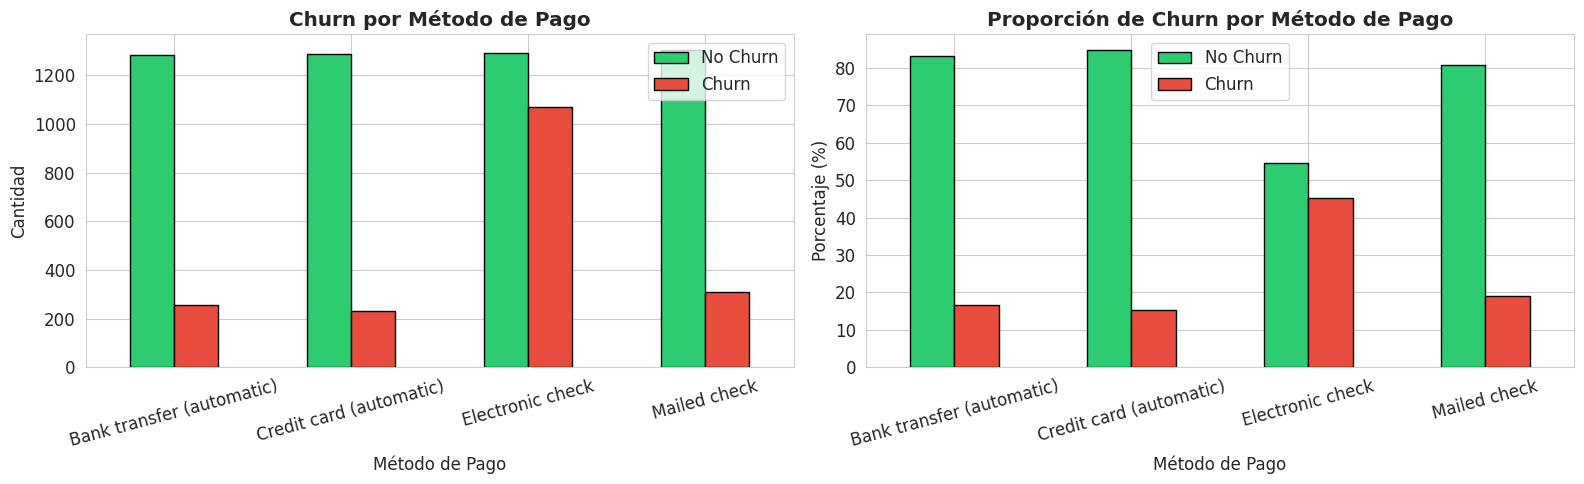


Tasa de Churn por método de pago:
  Mailed check: 19.1%
  Electronic check: 45.3%
  Bank transfer (automatic): 16.7%
  Credit card (automatic): 15.2%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pm_cross = pd.crosstab(df['Payment Method'], df['Churn Label'], normalize='index') * 100
pm_counts = pd.crosstab(df['Payment Method'], df['Churn Label'])

pm_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn por Método de Pago', fontweight='bold')
axes[0].set_xlabel('Método de Pago')
axes[0].set_ylabel('Cantidad')
axes[0].legend(['No Churn', 'Churn'])
axes[0].tick_params(axis='x', rotation=15)

pm_cross.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Proporción de Churn por Método de Pago', fontweight='bold')
axes[1].set_xlabel('Método de Pago')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['No Churn', 'Churn'])
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../reports/figures/payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTasa de Churn por método de pago:")
for pm in df['Payment Method'].unique():
    subset = df[df['Payment Method'] == pm]
    rate = subset['Churn Value'].mean() * 100
    print(f"  {pm}: {rate:.1f}%")

### 10.4 Online Security y Tech Support

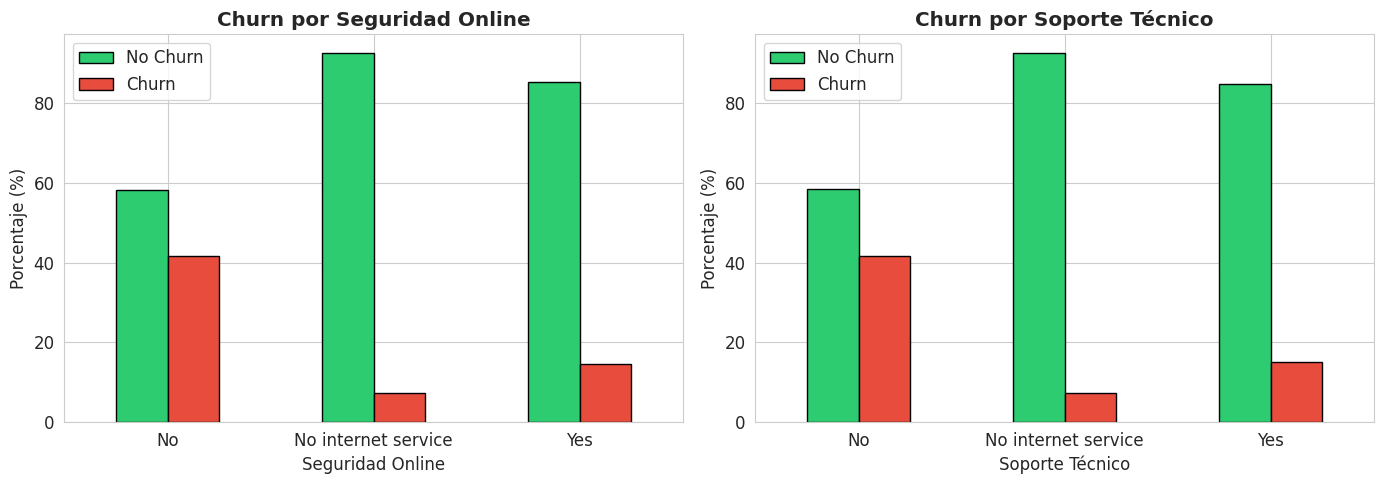


Tasa de Churn por Online Security:
  Yes: 14.6%
  No: 41.8%
  No internet service: 7.4%

Tasa de Churn por Tech Support:
  No: 41.6%
  Yes: 15.2%
  No internet service: 7.4%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col, title) in enumerate([
    ('Online Security', 'Seguridad Online'),
    ('Tech Support', 'Soporte Técnico')
]):
    cross = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    cross.plot(kind='bar', ax=axes[idx], color=colors, edgecolor='black')
    axes[idx].set_title(f'Churn por {title}', fontweight='bold')
    axes[idx].set_xlabel(title)
    axes[idx].set_ylabel('Porcentaje (%)')
    axes[idx].legend(['No Churn', 'Churn'])
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/security_support_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

for col in ['Online Security', 'Tech Support']:
    print(f"\nTasa de Churn por {col}:")
    for val in df[col].unique():
        subset = df[df[col] == val]
        rate = subset['Churn Value'].mean() * 100
        print(f"  {val}: {rate:.1f}%")

### 10.5 Paperless Billing

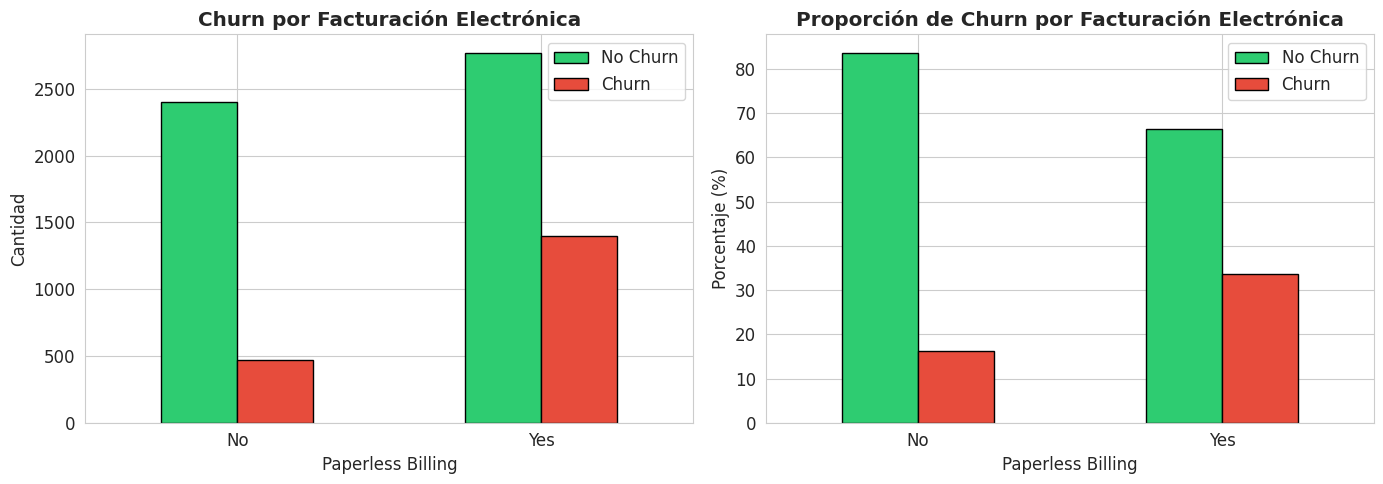


Tasa de Churn por Paperless Billing:
  Yes: 33.6%
  No: 16.3%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pb_cross = pd.crosstab(df['Paperless Billing'], df['Churn Label'], normalize='index') * 100
pb_counts = pd.crosstab(df['Paperless Billing'], df['Churn Label'])

pb_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn por Facturación Electrónica', fontweight='bold')
axes[0].set_xlabel('Paperless Billing')
axes[0].set_ylabel('Cantidad')
axes[0].legend(['No Churn', 'Churn'])
axes[0].tick_params(axis='x', rotation=0)

pb_cross.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Proporción de Churn por Facturación Electrónica', fontweight='bold')
axes[1].set_xlabel('Paperless Billing')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['No Churn', 'Churn'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/paperless_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTasa de Churn por Paperless Billing:")
for pb in df['Paperless Billing'].unique():
    subset = df[df['Paperless Billing'] == pb]
    rate = subset['Churn Value'].mean() * 100
    print(f"  {pb}: {rate:.1f}%")

## 11. Análisis de Correlaciones

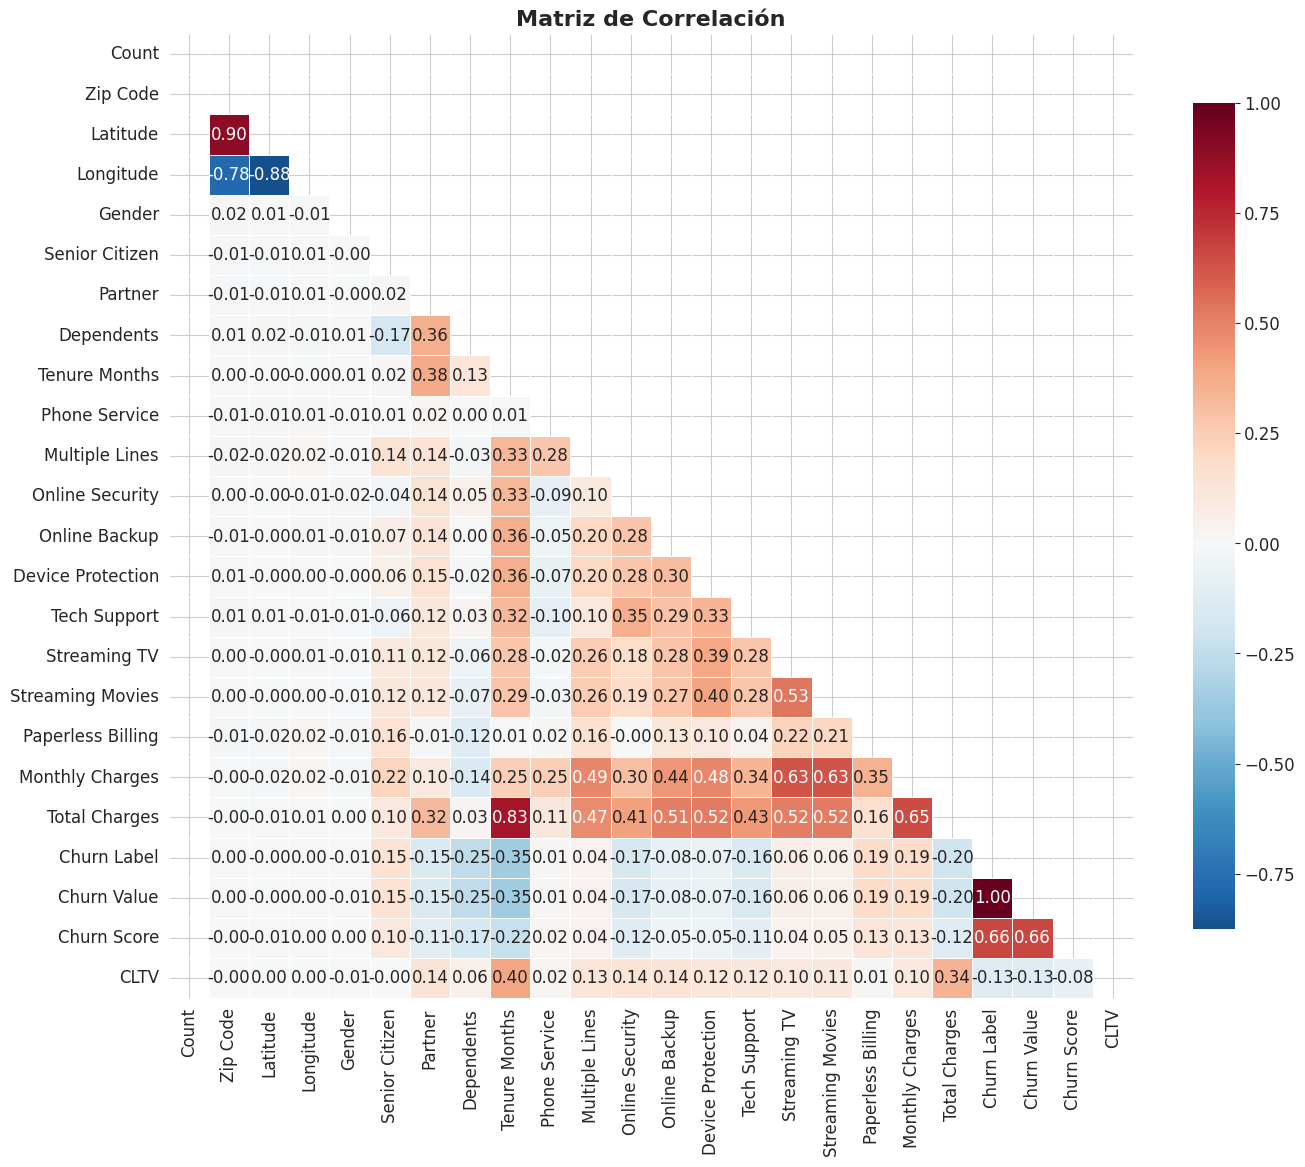

In [17]:
# Preparar datos para correlación
df_corr = df.copy()
df_corr['Total Charges'] = pd.to_numeric(df_corr['Total Charges'], errors='coerce')

# Codificar variables binarias para correlación
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'No phone service': 0, 'No internet service': 0}
for col in df_corr.select_dtypes('object').columns:
    if df_corr[col].nunique() <= 3:
        df_corr[col] = df_corr[col].map(binary_map).fillna(df_corr[col])

# Seleccionar columnas numéricas
num_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()

# Matriz de correlación
plt.figure(figsize=(14, 12))
corr_matrix = df_corr[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Correlación con Churn Value

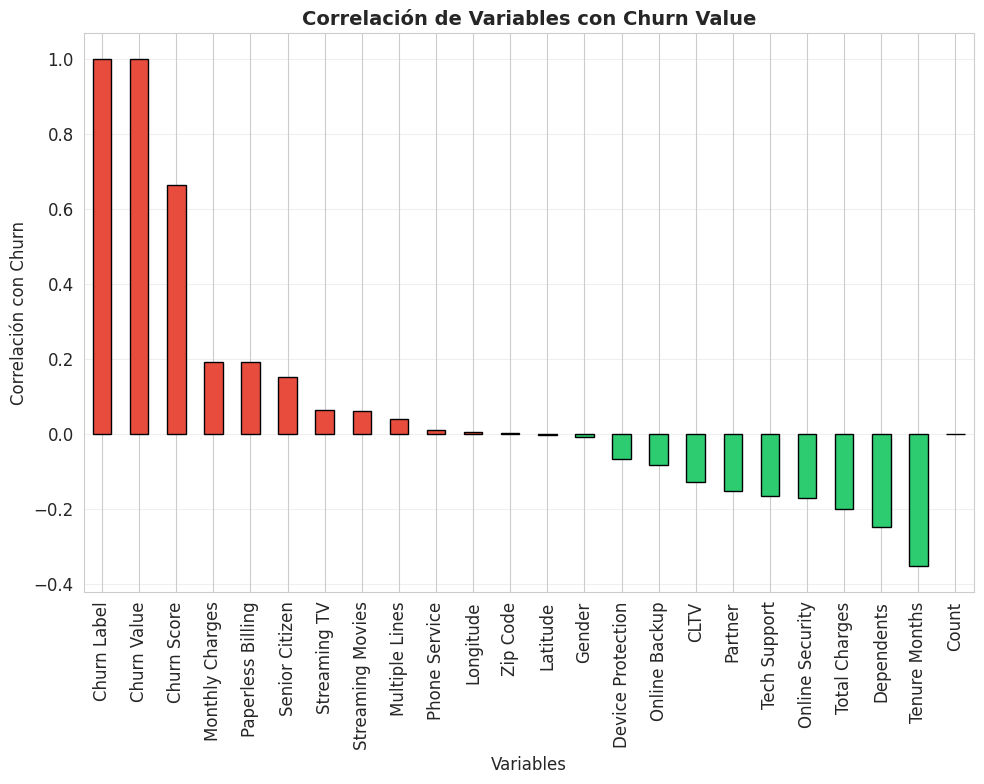


Correlación con Churn Value:
  Churn Label: 1.0000
  Churn Value: 1.0000
  Churn Score: 0.6649
  Monthly Charges: 0.1934
  Paperless Billing: 0.1918
  Senior Citizen: 0.1509
  Streaming TV: 0.0632
  Streaming Movies: 0.0614
  Multiple Lines: 0.0401
  Phone Service: 0.0119
  Longitude: 0.0046
  Zip Code: 0.0033
  Latitude: -0.0034
  Gender: -0.0086
  Device Protection: -0.0662
  Online Backup: -0.0823
  CLTV: -0.1275
  Partner: -0.1504
  Tech Support: -0.1647
  Online Security: -0.1712
  Total Charges: -0.1995
  Dependents: -0.2485
  Tenure Months: -0.3522
  Count: nan


In [18]:
corr_with_churn = corr_matrix['Churn Value'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
colors_corr = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_churn.values]
corr_with_churn.plot(kind='bar', color=colors_corr, edgecolor='black')
plt.title('Correlación de Variables con Churn Value', fontsize=14, fontweight='bold')
plt.xlabel('Variables')
plt.ylabel('Correlación con Churn')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/corr_with_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelación con Churn Value:")
for var, corr_val in corr_with_churn.items():
    print(f"  {var}: {corr_val:.4f}")

## 13. Pairplot de Variables Numéricas

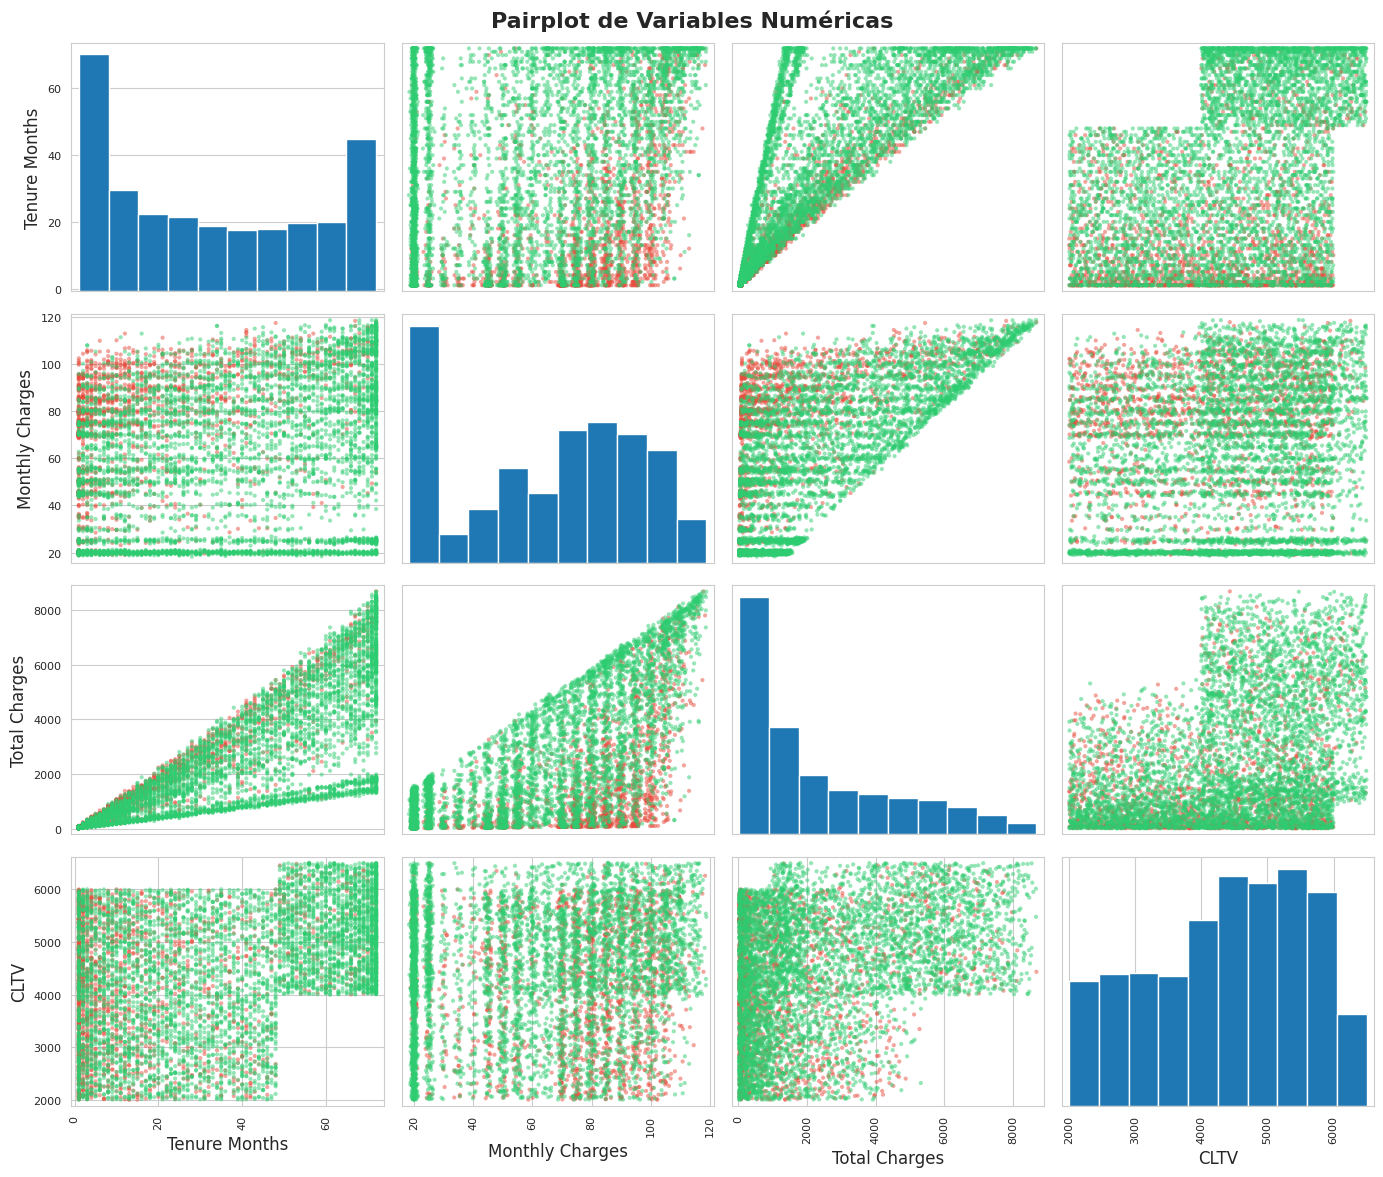

In [19]:
from pandas.plotting import scatter_matrix

numerical_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
X_plot = df_plot[numerical_features].copy()
X_plot['Churn'] = df_plot['Churn Label']

X_plot = X_plot.dropna()

colors = (
    (X_plot['Churn'] == 'Yes')
    .map({True: '#e74c3c', False: '#2ecc71'})
)

scatter_matrix(
    X_plot[numerical_features],
    figsize=(14,12),
    alpha=0.5,
    c=colors,
    diagonal='hist'
)
#X_plot = df_plot[numerical_features].copy()
#X_plot['Churn'] = df_plot['Churn Label']

#scatter_matrix(X_plot, figsize=(14, 12), alpha=0.5, c=(X_plot['Churn'] == 'Yes').map({True: '#e74c3c', False: '#2ecc71'}),
#               diagonal='hist')
plt.suptitle('Pairplot de Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Resumen del EDA

### Hallazgos Principales:

1. **Desbalance de clases:** 73.5% No Churn vs 26.5% Churn
2. **Variables clave para churn:**
   - `Contract`: Clientes con contrato mensual tienen mayor tasa de churn (~42%)
   - `Tenure Months`: Clientes con menor antigüedad abandonan más
   - `Internet Service`: Fibra óptica tiene mayor churn
   - `Online Security` y `Tech Support`: Ausencia aumenta el churn
   - `Payment Method`: Pagos electrónicos tienen mayor churn
   - `Paperless Billing`: Clientes con facturación electrónica abandonan más
3. **Sin valores nulos** (excepto Churn Reason, que es esperado)
4. **Sin duplicados**
5. `Total Charges` necesita conversión a numérico

## 15. Guardar Datos Procesados

In [20]:
# Guardar una copia limpia para la siguiente fase
df_clean = df_plot.copy()
df_clean.to_csv('../data/processed/telco_clean.csv', index=False)
print("Datos limpios guardados en data/processed/telco_clean.csv")

Datos limpios guardados en data/processed/telco_clean.csv
